In [18]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [105]:
data = pd.read_csv('cs-training.csv').drop(columns=['Unnamed: 0'])

- **target**: Дефолт (просрочка 90+ дней в течение 2 лет)
- **delq_30_59**: Кол-во просрочек 30-59 дней (последние 2 года)
- **delq_60_89**: Кол-во просрочек 60-89 дней (последние 2 года)
- **delq_90_plus**: Кол-во просрочек 90+ дней (вся история, кроме периода таргета)
- **credit_util**: Утилизация кредитных карт (0-1 или >1 если большие долги)
- **credit_cards**: Всего открытых кредитных линий/карт
- **estate_cnt**: Кол-во ипотек / кредитов под залог недвижимости
- **age**: Возраст заемщика (в годах)
- **monthly_salary**: Ежемесячный доход (доллар США)
- **debt_ratio**: Долговая нагрузка (ежемес.платежи / доход)
- **dependents_cnt**: Кол-во иждивенцев

In [106]:
rename_dict = {
    'SeriousDlqin2yrs': 'target',

    'NumberOfTime30-59DaysPastDueNotWorse': 'delq_30_59',
    'NumberOfTime60-89DaysPastDueNotWorse': 'delq_60_89',
    'NumberOfTimes90DaysLate': 'delq_90_plus',
    
    'RevolvingUtilizationOfUnsecuredLines': 'credit_util',
    'NumberOfOpenCreditLinesAndLoans': 'credit_cards',
    'NumberRealEstateLoansOrLines': 'estate_cnt',
    
    'age': 'age',
    'MonthlyIncome': 'monthly_salary',
    'DebtRatio': 'debt_ratio',
    
    'NumberOfDependents': 'dependents_cnt'
}

data = data.rename(columns=rename_dict)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   target          150000 non-null  int64  
 1   credit_util     150000 non-null  float64
 2   age             150000 non-null  int64  
 3   delq_30_59      150000 non-null  int64  
 4   debt_ratio      150000 non-null  float64
 5   monthly_salary  120269 non-null  float64
 6   credit_cards    150000 non-null  int64  
 7   delq_90_plus    150000 non-null  int64  
 8   estate_cnt      150000 non-null  int64  
 9   delq_60_89      150000 non-null  int64  
 10  dependents_cnt  146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


Начнем с обработки пропусков, они присутствуют в переменных **monthly_salary** и **dependents_cnt**. Посмотрим на их распределения

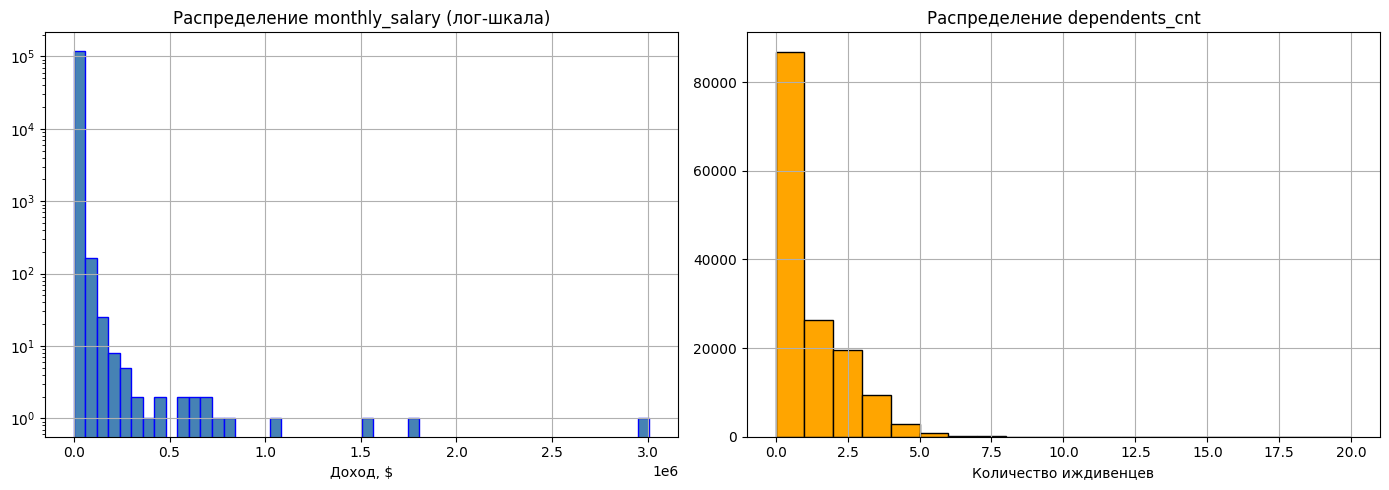

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма monthly_salary
data['monthly_salary'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='blue')
axes[0].set_title('Распределение monthly_salary (лог-шкала)', fontsize=12)
axes[0].set_yscale('log')
axes[0].set_xlabel('Доход, $')

data['dependents_cnt'].hist(bins=20, ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Распределение dependents_cnt', fontsize=12)
axes[1].set_xlabel('Количество иждивенцев')

plt.tight_layout()

plt.show()


Посмотрим как связаны пропуски в этих переменных с таргетом

In [107]:
data['salary_missing_flag'] = data['monthly_salary'].isnull().astype(int)
salary_default_rate = data.groupby('salary_missing_flag')['target'].mean()
print(f"Есть данные о доходе: {salary_default_rate[0]:.4f} default rate")
print(f"Пропущен доход:     {salary_default_rate[1]:.4f} default rate")
print(f"Разница:            {salary_default_rate[1] - salary_default_rate[0]:+.4f}\n")

Есть данные о доходе: 0.0695 default rate
Пропущен доход:     0.0561 default rate
Разница:            -0.0133



In [108]:
data['dependents_missing_flag'] = data['dependents_cnt'].isnull().astype(int)
dependents_default_rate = data.groupby('dependents_missing_flag')['target'].mean()
print(f"Есть данные об иждивенцах: {dependents_default_rate[0]:.4f} default rate")
print(f"Пропущены иждивенцы:      {dependents_default_rate[1]:.4f} default rate")
print(f"Разница:                  {dependents_default_rate[1] - dependents_default_rate[0]:+.4f}")

Есть данные об иждивенцах: 0.0674 default rate
Пропущены иждивенцы:      0.0456 default rate
Разница:                  -0.0218


Видим, что те, кто не указал доход или иждивенцев, реже просрочивали платежи по кредиту. Возможно, те кто не указывает доходы, скрывает их, и можно сделать вывод, что такие люди более обеспеченные. Те, кто не указал иждивенцев, скорее всего их и не имеют, значит холостяки. У них меньше финансовая нагрузка, поэтому они лучше выплачивают кредиты

Тогда мы оставим информацию о тех, кто не указывал зарплату в отдельной переменной, пропуски заменим медианой. А пропуски в иждивенцах заполним нулями

In [109]:
# Рассчитываем групповую медиану по возрасту и кол-ву кредиток, чтобы сохранить распределение

data['age_group'] = (data['age'] // 10) * 10
data['cards_group'] = pd.cut(data['credit_cards'], bins=[0, 2, 5, 100], labels=['1-2', '3-5', '6+'])

group_medians = data.groupby(['age_group', 'cards_group'], observed=True)['monthly_salary'].median().reset_index()
group_medians.columns = ['age_group', 'cards_group', 'salary_group_median']

data = data.merge(group_medians, on=['age_group', 'cards_group'], how='left')

# На всякий случай, если будут пропуски, рассчитываем медиану по возрасту

age_medians = data.groupby('age_group')['monthly_salary'].median().reset_index()
age_medians.columns = ['age_group', 'salary_age_median']

data = data.merge(age_medians, on='age_group', how='left')

# Заполняем пропуски по уровням

data['monthly_salary'] = data['monthly_salary'].fillna(data['salary_group_median'])
data['monthly_salary'] = data['monthly_salary'].fillna(data['salary_age_median'])
data['monthly_salary'] = data['monthly_salary'].fillna(data['monthly_salary'].median())

# Пропуски иждивенцев

data['dependents_cnt'] = data['dependents_cnt'].fillna(0)

data = data.drop(columns=['salary_group_median', 'salary_age_median', 'age_group', 'cards_group'])

Пропуски заполнили, теперь перейдем к работе с выбросами. Просто так их удалить будет некорректно, поэтому будем анализировать

In [110]:
cols = [c for c in data.columns.tolist() if c != 'target']

stats = data[cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T
stats['iq_ratio'] = stats['99%'] / (stats['mean'] + 1)  # отношение 99-го перцентиля к среднему
print(stats[['min', 'mean', 'max', '99%', 'iq_ratio']].round(2))

                         min     mean        max       99%  iq_ratio
credit_util              0.0     6.05    50708.0      1.09      0.16
age                      0.0    52.30      109.0     87.00      1.63
delq_30_59               0.0     0.42       98.0      4.00      2.81
debt_ratio               0.0   353.01   329664.0   4979.04     14.06
monthly_salary           0.0  6394.39  3008750.0  23000.00      3.60
credit_cards             0.0     8.45       58.0     24.00      2.54
delq_90_plus             0.0     0.27       98.0      3.00      2.37
estate_cnt               0.0     1.02       54.0      4.00      1.98
delq_60_89               0.0     0.24       98.0      2.00      1.61
dependents_cnt           0.0     0.74       20.0      4.00      2.30
salary_missing_flag      0.0     0.20        1.0      1.00      0.83
dependents_missing_flag  0.0     0.03        1.0      1.00      0.97


Разберемся по всем столбцам. **credit_cards**, **estate_cnt**, **dependents_cnt** в целом достаточно корректные, можно немного исправить.  
  
Столбцы **delq_30_59**, **delq_60_89**, **delq_90_plus** имеют значение 98, скорее всего это не баг, а какой-то хронический нарушитель. Можно убрать выбросы по 99 перцентилю, и сделать флаг для всех значений, которые больше него;   
  
**credit_util** содержит ошибку данных;  
  
в столбце **age** стоит убрать нулевой возраст, обрезать с 18 по 85;   
  
**monthly_salary** содержит огромное значение, поэтому его стоит также обрезать по 99 перцентилю  
  
**debt_ratio** самый плохой столбец. В нем рассчитывается отношение ежемесячных платежей к зарплате, и при зарплате 0 он может быть огромным. Среднее 353, хотя должно быть < 1. Стоит заменить нулевые зарплаты и пересчитать это значение, для остальных обрезать по 99 перцентилю, и также можно создать флаг для значений, которые больше него

In [112]:
# Обрезаем возраст

data = data[(data['age'] >= 18) & (data['age'] <= 85)]

# Заменяем нулевые зарплаты

data['salary_was_zero'] = (data['monthly_salary'] == 0).astype(int)
median = data.loc[data['salary_missing_flag'] == 0, 'monthly_salary'].median()
data.loc[data['monthly_salary'] == 0, 'monthly_salary'] = median

data['monthly_salary'] = data['monthly_salary'].clip(upper=data['monthly_salary'].quantile(0.99))

# Работаем с debt_ratio

debt_quant = data['debt_ratio'].quantile(0.99)
data['debt_ratio_extreme'] = (data['debt_ratio'] > debt_quant).astype(int)
data['debt_ratio'] = data['debt_ratio'].clip(upper=debt_quant)

# credit_util

data['credit_util_extreme'] = (data['credit_util'] > 1.0).astype(int)
util_quant = data['credit_util'].quantile(0.99)
data['credit_util'] = data['credit_util'].clip(upper=util_quant)

# Просрочки

cols = ['delq_30_59', 'delq_60_89', 'delq_90_plus']
delq_quants = {}
for col in cols:
    delq_quants[col] = data[col].quantile(0.99)

data['delq_extreme'] = (
    (data['delq_30_59'] > delq_quants['delq_30_59']) |
    (data['delq_60_89'] > delq_quants['delq_60_89']) |
    (data['delq_90_plus'] > delq_quants['delq_90_plus'])
).astype(int)

for col in cols:
    data[col] = data[col].clip(upper=delq_quants[col])

# Винзоризация остальных данных

for col in ['credit_cards', 'estate_cnt', 'dependents_cnt']:
    quant = data[col].quantile(0.995)
    if (data[col] > quant).sum() > 0:
        data[col] = data[col].clip(upper=quant)

In [113]:
cols = [c for c in data.columns.tolist() if c != 'target']

stats = data[cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T
stats['iq_ratio'] = stats['99%'] / (stats['mean'] + 1)  # отношение 99-го перцентиля к среднему
print(stats[['min', 'mean', 'max', '99%', 'iq_ratio']].round(2))

                          min     mean       max       99%  iq_ratio
credit_util               0.0     0.32      1.10      1.10      0.83
age                      21.0    51.79     85.00     82.00      1.55
delq_30_59                0.0     0.25      4.00      4.00      3.21
debt_ratio                0.0   319.55   4996.84   4996.35     15.59
monthly_salary            1.0  6200.56  23184.34  23177.76      3.74
credit_cards              0.0     8.46     27.00     24.00      2.54
delq_90_plus              0.0     0.09      3.00      3.00      2.76
estate_cnt                0.0     1.02      6.00      4.42      2.19
delq_60_89                0.0     0.06      2.00      2.00      1.88
dependents_cnt            0.0     0.74      5.00      4.00      2.29
salary_missing_flag       0.0     0.20      1.00      1.00      0.84
dependents_missing_flag   0.0     0.02      1.00      1.00      0.98
salary_was_zero           0.0     0.01      1.00      1.00      0.99
debt_ratio_extreme        0.0     

Теперь везде у нас корерктные значения, нет каких-то аномалий, а также мы зафиксировали в отдельных переменных экстремальные значения

Приступим к созданию новых признаков

In [ ]:
# Доход на одного члена семьи
data['salary_per_person'] = data['monthly_salary'] / (data['dependents_cnt'] + 1)

# Платежная нагрузка
data['monthly_debt'] = data['debt_ratio'] * data['monthly_salary']

# Остаток денег после выплат
data['money_left'] = data['monthly_salary'] - data['monthly_debt']

# Общее количество просрочек
data['delq_total'] = data['delq_30_59'] + data['delq_60_89'] + data['delq_90_plus']

# Взвешенная сума просрочек
data['delq_weighted_score'] = (
    data['delq_30_59'] * 1 +
    data['delq_60_89'] * 3 +
    data['delq_90_plus'] * 10
)

# Были ли просрочки вообще
data['delq_ever_30'] = (data['delq_30_59'] > 0).astype(int)
data['delq_ever_60'] = (data['delq_60_89'] > 0).astype(int)
data['delq_ever_90'] = (data['delq_90_plus'] > 0).astype(int)

# Соотношение кредитных карт к ипотекам
data['credit_estate'] = data['credit_cards'] / (data['estate_cnt'] + 1)

# Метрика риска, долги * просрочки
data['risk_debt'] = data['credit_util'] * data['delq_weighted_score']

# Финансовый стресс
median = data['monthly_salary'].median()
data['risk_financial_stress'] = (
    (data['debt_ratio'] > 0.4) & 
    (data['monthly_salary'] < median)
).astype(int)

# Идеальный заемщик
data['risk_prime_client'] = (
    (data['delq_total'] == 0) &
    (data['credit_util'] < 0.3) &
    (data['debt_ratio'] < 0.3) &
    (data['monthly_salary'] > median)
).astype(int)

KeyError: 'delq_total_cnt'

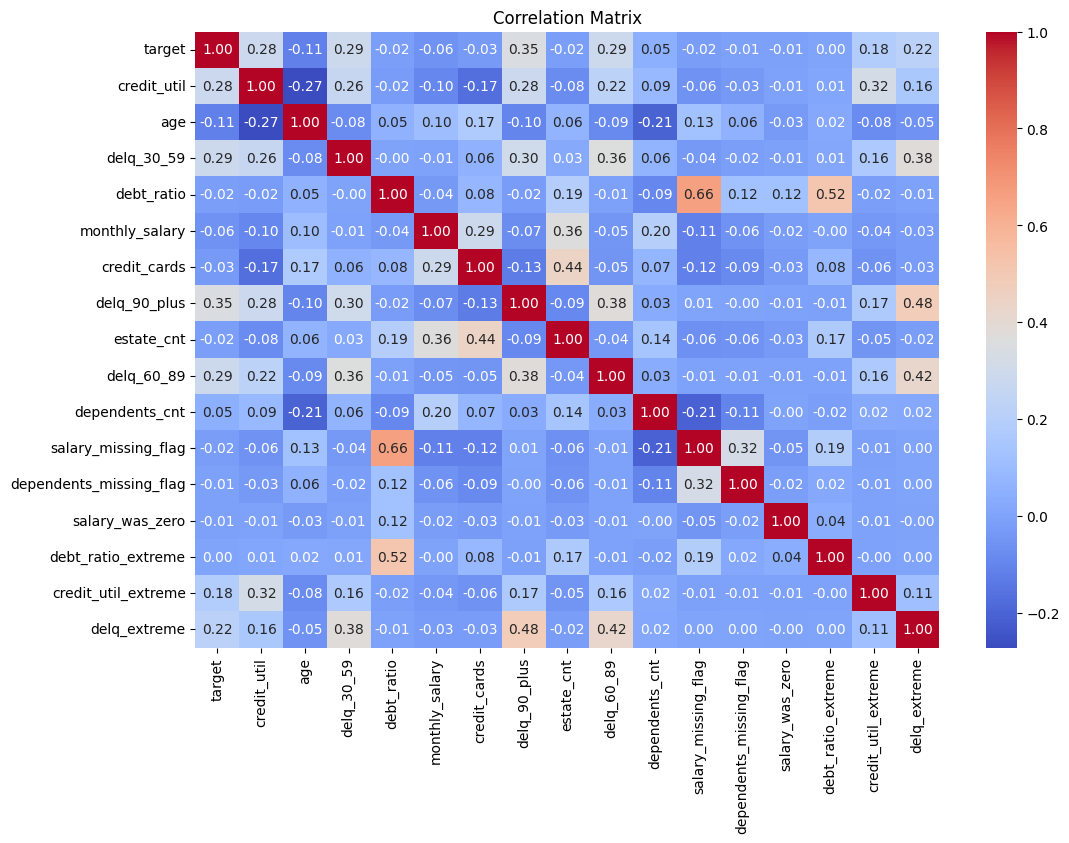

In [115]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()